## Load Data

 - Loading from `final_dataset_with_y.csv`
 - Must upload it to files beforehand

In [ ]:
import pandas as pd

# Assuming the CSV file is named 'data.csv' and is in the current directory
# If your file has a different name or path, please update 'data.csv' accordingly.
df = pd.read_csv('final_dataset_with_y.csv')

# Display the first few rows of the DataFrame to verify it loaded correctly
print(df.head())

                     repo_name  is_fork fork_owner_type  \
0             eowyncim/snarkOS     True            User   
1        sumitpatro143/minimal     True            User   
2  olduma/layout_product-cards     True            User   
3   crucial-keydev/Spoon-Knife     True            User   
4       nanimonii/hello-uniapp     True            User   

                  created_at  total_commits  commit_frequency_per_week  \
0  2023-12-04 17:02:26+00:00              0                   0.000000   
1  2024-01-03 00:57:14+00:00              1                   0.038462   
2  2024-01-31 07:35:47+00:00              1                   0.038462   
3  2024-01-23 20:40:25+00:00              0                   0.000000   
4  2023-12-11 07:54:24+00:00              0                   0.000000   

   unique_commit_authors  issues_opened  issues_closed  issue_close_rate  ...  \
0                      0              0              0               NaN  ...   
1                      1              

## Preprocess Data



In [ ]:
y = df['is_sustainable']
X = df.drop(columns=['is_sustainable', 'repo_name', 'created_at', 'parent_created_at', 'topics'])

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (48686, 36)
Shape of y: (48686,)


In [ ]:
numerical_cols = X.select_dtypes(include=['number']).columns
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns

# Impute missing values for numerical columns with the median
for col in numerical_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

# Impute missing values for categorical columns with the mode
for col in categorical_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].mode()[0])

# Convert boolean columns to int (0 or 1) before one-hot encoding if not already handled
for col in X.select_dtypes(include=['bool']).columns:
    X[col] = X[col].astype(int)

# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Shape of X after preprocessing: {X.shape}")
print(f"Columns in X after preprocessing: {X.columns.tolist()}")

/tmp/ipykernel_12092/1443635114.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].fillna(X[col].mode()[0])


Shape of X after preprocessing: (48686, 28509)
Columns in X after preprocessing: ['total_commits', 'commit_frequency_per_week', 'unique_commit_authors', 'issues_opened', 'issues_closed', 'issue_close_rate', 'prs_opened', 'prs_merged', 'prs_rejected', 'pr_acceptance_rate', 'num_releases', 'star_count', 'fork_count', 'total_issue_comments', 'total_pr_comments', 'avg_issue_first_response_hrs', 'avg_pr_first_response_hrs', 'bus_factor', 'contributor_gini', 'retention_m3', 'retention_m6', 'months_to_first_external_contrib', 'parent_stars', 'parent_forks', 'early_commits_on_branch', 'parent_early_commits', 'divergence_ratio', 'fork_owner_type_User', 'has_contributing_1', 'has_code_of_conduct_1', 'has_license_1', 'has_cicd_1', 'parent_repo_007-Shivam/Sanket', 'parent_repo_007revad/Synology_HDD_db', 'parent_repo_007revad/Synology_enable_M2_volume', 'parent_repo_00aj99/Teardroid-phprat', 'parent_repo_00nktk/volsa2', 'parent_repo_01-ai/Yi', 'parent_repo_01-edu/public', 'parent_repo_01abhaysharma

## Split data into training set and testing set

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (38948, 28509)
Shape of X_test: (9738, 28509)
Shape of y_train: (38948,)
Shape of y_test: (9738,)


### Handle Class Imbalance with `scale_pos_weight`

Given the significant class imbalance, we will use the `scale_pos_weight` parameter in the XGBoost classifier. This parameter is used to handle imbalanced datasets by giving more importance to the minority class. The typical value for `scale_pos_weight` is `count(negative examples) / count(positive examples)`.

In [ ]:
# Calculate the scale_pos_weight
neg_count = class_counts[0]
pos_count = class_counts[1]
scale_pos_weight_value = neg_count / pos_count

print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.2f}")

# Initialize the XGBoost Classifier with scale_pos_weight
xgb_model_balanced = XGBClassifier(
    random_state=42,
    eval_metric=['logloss','auc','error'],
    scale_pos_weight=scale_pos_weight_value
)

# Train the balanced model
xgb_model_balanced.fit(X_train, y_train)

print("XGBoost model training with scale_pos_weight complete.")

Calculated scale_pos_weight: 71.88
XGBoost model training with scale_pos_weight complete.


### Evaluate Balanced Model

Let's evaluate the performance of the model after applying `scale_pos_weight`.

In [ ]:
y_score_balanced = xgb_model_balanced.predict_proba(X_test)[:,1]
auc_balanced = get_auc(y_test, y_score_balanced)

y_pred_balanced = xgb_model_balanced.predict(X_test)

f1_balanced = f1_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)

print(f"Balanced Model AUC: {auc_balanced:.4f}")
print(f"Balanced Model F1 Score: {f1_balanced:.4f}")
print(f"Balanced Model Recall: {recall_balanced:.4f}")

Balanced Model AUC: 0.9100
Balanced Model F1 Score: 0.2992
Balanced Model Recall: 0.6715


### Optimize F1 Score by Adjusting Classification Threshold

The F1 score is a balance between precision and recall. When working with imbalanced datasets, it's often beneficial to adjust the classification threshold (which is typically 0.5 by default) to find a sweet spot that maximizes F1. Let's analyze precision, recall, and F1 score across a range of possible thresholds.

Optimal Threshold for F1 Score: 0.9050
Maximum F1 Score at optimal threshold: 0.4423


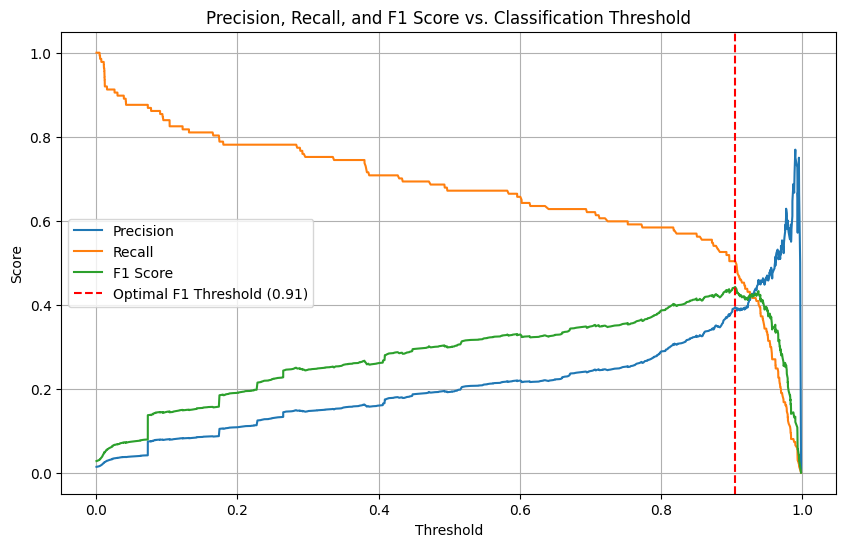

In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class from the balanced model
y_scores = xgb_model_balanced.predict_proba(X_test)[:, 1]

# Calculate precision, recall, and thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# Calculate F1 scores for each threshold
f1_scores = []
for i in range(len(precisions) - 1):
    f1 = 2 * (precisions[i] * recalls[i]) / (precisions[i] + recalls[i]) if (precisions[i] + recalls[i]) > 0 else 0
    f1_scores.append(f1)

# Find the threshold that maximizes the F1 score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
max_f1_score = f1_scores[optimal_idx]

print(f"Optimal Threshold for F1 Score: {optimal_threshold:.4f}")
print(f"Maximum F1 Score at optimal threshold: {max_f1_score:.4f}")

# Plot Precision, Recall, and F1 Score vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores, label='F1 Score')
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal F1 Threshold ({optimal_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Classification Threshold')
plt.legend()
plt.grid(True)
plt.show()

### Evaluate Model with Optimal Threshold

Now, let's re-evaluate the balanced model using the optimal threshold found to see the improved F1 score.

In [ ]:
# Predict classes using the optimal threshold
y_pred_optimal_threshold = (y_scores >= optimal_threshold).astype(int)

# Calculate F1 score and Recall with the optimal threshold
f1_optimal = f1_score(y_test, y_pred_optimal_threshold)
recall_optimal = recall_score(y_test, y_pred_optimal_threshold)

auc_optimal = get_auc(y_test, y_pred_optimal_threshold)

print(f"F1 Score with Optimal Threshold: {f1_optimal:.4f}")
print(f"Recall with Optimal Threshold: {recall_optimal:.4f}")
print(f"AUC with Optimal Threshold: {auc_optimal:.4f}")

F1 Score with Optimal Threshold: 0.4423
Recall with Optimal Threshold: 0.5036
AUC with Optimal Threshold: 0.7463


## Export Model

After running, we can download model from 'xgboost_model.pkl'.


In [ ]:
import pickle

# Open a file in write-binary mode and save the model
with open('xgboost_model.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)

print("XGBoost model saved successfully to 'xgboost_model.pkl'")

XGBoost model saved successfully to 'xgboost_model.pkl'
